Importing libraries for preprocessing and modeling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc
)

Loading dataset and previewing data structure


In [ ]:
# Loading dataset
data = pd.read_csv('/content/Network_dataset_1.csv')
# checking dataset shape
print("Dataset Shape:", data.shape)
# displaying first rows
data.head()

/tmp/ipykernel_4740/1218709519.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/Network_dataset_1.csv')


Dataset Shape: (782422, 46)


,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0.0,0.0,-,-,-,bad_TCP_checksum,-,F,0.0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0.0,0.0,-,-,-,bad_TCP_checksum,-,F,0.0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,0.0,0.0,-,-,-,bad_UDP_checksum,-,F,0.0,normal


Checking dataset structure and data types

In [ ]:
print('Info of the Network Dataset is: ')
data.info()

Info of the Network Dataset is: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782422 entries, 0 to 782421
Data columns (total 46 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ts                      782422 non-null  int64  
 1   src_ip                  782422 non-null  object 
 2   src_port                782422 non-null  int64  
 3   dst_ip                  782422 non-null  object 
 4   dst_port                782422 non-null  int64  
 5   proto                   782422 non-null  object 
 6   service                 782422 non-null  object 
 7   duration                782422 non-null  float64
 8   src_bytes               782422 non-null  object 
 9   dst_bytes               782422 non-null  int64  
 10  conn_state              782422 non-null  object 
 11  missed_bytes            782422 non-null  int64  
 12  src_pkts                782422 non-null  int64  
 13  src_ip_bytes            782422 non-null  

Checking missing values across dataset

In [ ]:
# checking missing values
print("Missing values:\n", data.isnull().sum())

Missing values:
 ts                        0
src_ip                    0
src_port                  0
dst_ip                    0
dst_port                  0
proto                     0
service                   0
duration                  0
src_bytes                 0
dst_bytes                 0
conn_state                0
missed_bytes              0
src_pkts                  0
src_ip_bytes              0
dst_pkts                  0
dst_ip_bytes              0
dns_query                 0
dns_qclass                0
dns_qtype                 0
dns_rcode                 0
dns_AA                    0
dns_RD                    0
dns_RA                    0
dns_rejected              0
ssl_version               0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_referrer             0
http_version              0
htt

Identifying and displaying duplicate records

In [ ]:
# checking duplicate rows
print("\nDuplicate rows:", data.duplicated().sum())
# showing both original and duplicate rows
paired_duplicates = data[data.duplicated(keep=False)]
paired_duplicates.head(20)


Duplicate rows: 6425


,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
12678,1554220499,192.168.1.250,5353,224.0.0.251,5353,udp,dns,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12679,1554220499,192.168.1.250,5353,224.0.0.251,5353,udp,dns,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12697,1554220514,192.168.1.133,5353,224.0.0.251,5353,udp,dns,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12699,1554220514,192.168.1.133,5353,224.0.0.251,5353,udp,dns,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12812,1554220595,192.168.1.133,5353,224.0.0.251,5353,udp,dns,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12813,1554220595,192.168.1.133,5353,224.0.0.251,5353,udp,dns,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12994,1554220744,192.168.1.79,43029,192.168.1.255,15600,udp,-,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
12996,1554220744,192.168.1.79,43029,192.168.1.255,15600,udp,-,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
13122,1554220864,192.168.1.195,138,192.168.1.255,138,udp,-,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal
13124,1554220864,192.168.1.195,138,192.168.1.255,138,udp,-,0.0,0,0,...,0.0,0.0,-,-,-,-,-,-,0.0,normal


Removing duplicate rows, keeping first occurrence

In [ ]:
# remove duplicate rows but keep the first occurrence
data = data.drop_duplicates(keep='first')
print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (775997, 46)


Analyzing class, attack, and data distributions

In [ ]:
# checking class distribution
print("\nLabel distribution:\n", data['label'].value_counts())
# checking attack types distribution
print("\nAttack types:\n", data['type'].value_counts())
# checking data types summary
print("\nData Types:\n", data.dtypes.value_counts())


Label distribution:
 label
1.0    573892
0.0    202104
Name: count, dtype: int64

Attack types:
 type
scanning    573892
normal      202104
Name: count, dtype: int64

Data Types:
 object     29
int64      12
float64     5
Name: count, dtype: int64


Generating descriptive statistics for dataset

In [ ]:
print("Descriptive Statistics Of The Dataset Is: ")
data.describe()

Descriptive Statistics Of The Dataset Is: 


,ts,src_port,dst_port,duration,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,7.759970e+05,775997.000000,775997.000000,775997.000000,7.759970e+05,7.759970e+05,775997.000000,7.759970e+05,775997.000000,7.759970e+05,775997.000000,775997.000000,775997.000000,775996.000000,7.759960e+05,775996.000000,775996.000000
mean,1.555590e+09,36286.609752,21483.127530,3.368783,2.421179e+03,7.170410e+02,3.449788,6.620455e+02,4.667032,1.796263e+03,76.144406,1.441132,0.011231,0.017791,3.930453e+01,0.066466,0.739555
std,7.535618e+05,18814.859150,20236.963208,209.121267,3.626513e+05,1.387338e+05,383.975017,1.004593e+05,629.671265,3.231591e+05,1577.267491,14.753520,0.182978,4.820531,1.589151e+04,3.715912,0.438878
min,1.554198e+09,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,1.554364e+09,21531.000000,3544.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,4.400000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,1.556026e+09,40472.000000,13177.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,1.556026e+09,52086.000000,40084.000000,0.000008,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,1.556026e+09,65535.000000,65535.000000,85274.354600,1.588564e+08,6.145087e+07,252181.000000,3.189700e+07,313943.000000,1.644688e+08,32769.000000,255.000000,3.000000,2338.000000,1.342438e+07,304.000000,1.000000


Analyzing feature uniqueness across dataset

In [ ]:
# checking unique count for each column
unique_counts = data.nunique()
# showing columns with very low uniqueness
print("Low unique columns:\n")
print(unique_counts[unique_counts <= 2])
# showing columns with very high uniqueness
print("\nHigh unique columns:\n")
print(unique_counts.sort_values(ascending=False).head(15))

Low unique columns:

http_referrer    1
http_version     2
weird_notice     2
label            2
type             2
dtype: int64

High unique columns:

ts              103064
dst_port         65420
src_port         65243
duration         64149
src_ip_bytes      2237
dst_ip_bytes      2195
src_bytes         1909
dst_bytes         1839
dst_ip            1489
dns_query         1317
missed_bytes       479
dst_pkts           403
src_pkts           392
src_ip              93
http_uri            66
dtype: int64


Calculating dash value counts and percentages

In [ ]:
# calculating '-' count
dash_count = (data == '-').sum()
# calculating '-' percentage
dash_percent = ((data == '-').sum() / len(data)) * 100
# creating summary table
dash_table = pd.DataFrame({
    'Dash_Count': dash_count,
    'Dash_Percentage': dash_percent
})
# sorting the table
dash_table = dash_table.sort_values(by='Dash_Count', ascending=False)
# showing top 25 sparse columns
dash_table.head(25)

,Dash_Count,Dash_Percentage
http_referrer,775997,100.000000
ssl_issuer,775988,99.998840
ssl_subject,775988,99.998840
http_orig_mime_types,775980,99.997809
http_resp_mime_types,775833,99.978866
http_method,775762,99.969716
http_uri,775762,99.969716
http_user_agent,775761,99.969588
http_version,775746,99.967655
http_trans_depth,775746,99.967655


Removing sparse columns with high dash percentage

In [ ]:
# identifying columns with >90% '-'
cols_to_remove = dash_table[dash_table['Dash_Percentage'] > 90].index
# dropping the cols having '-'
data = data.drop(cols_to_remove, axis=1)
print("Shape after removing sparse columns:", data.shape)

Shape after removing sparse columns: (775997, 23)


Removing identifier columns from dataset

In [ ]:
data = data.drop(['src_ip','dst_ip','ts'], axis=1)
print("Shape after removing identifiers:", data.shape)

Shape after removing identifiers: (775997, 20)


Checking remaining dash values and missing data

In [ ]:
# checking remaining '-' values
dash_remaining = (data == '-').sum()
# filtering columns where '-' still present
dash_cols = dash_remaining[dash_remaining > 0]
if len(dash_cols) > 0:
    print("Columns still having '-' values:\n")
    print(dash_cols.sort_values(ascending=False))
else:
    print("No columns contain '-' values now.")
print("Total missing values in dataset:", data.isnull().sum().sum())

No columns contain '-' values now.
Total missing values in dataset: 5


Displaying dataset structure and data types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775997 entries, 0 to 782421
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_port                775997 non-null  int64  
 1   dst_port                775997 non-null  int64  
 2   proto                   775997 non-null  object 
 3   duration                775997 non-null  float64
 4   src_bytes               775997 non-null  object 
 5   dst_bytes               775997 non-null  int64  
 6   conn_state              775997 non-null  object 
 7   missed_bytes            775997 non-null  int64  
 8   src_pkts                775997 non-null  int64  
 9   src_ip_bytes            775997 non-null  int64  
 10  dst_pkts                775997 non-null  int64  
 11  dst_ip_bytes            775997 non-null  int64  
 12  dns_qclass              775997 non-null  int64  
 13  dns_qtype               775997 non-null  int64  
 14  dns_rcode               7

Exploratory Data Analysis

/tmp/ipykernel_4740/2761761682.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=data, palette='Set2')


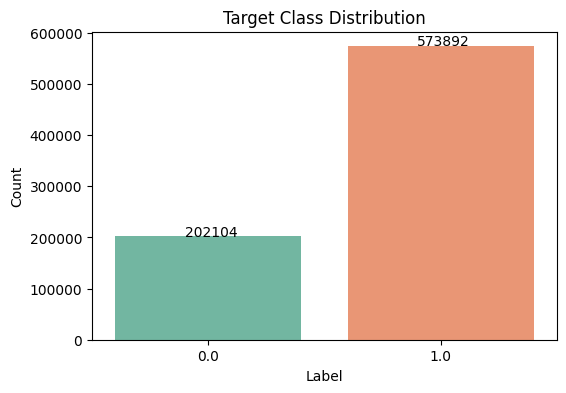

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='label', data=data, palette='Set2')

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+0.3, p.get_height()+1000))

plt.title("Target Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

Visualizing protocol distribution using countplot

/tmp/ipykernel_4740/853331834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='proto', data=data, palette='coolwarm')


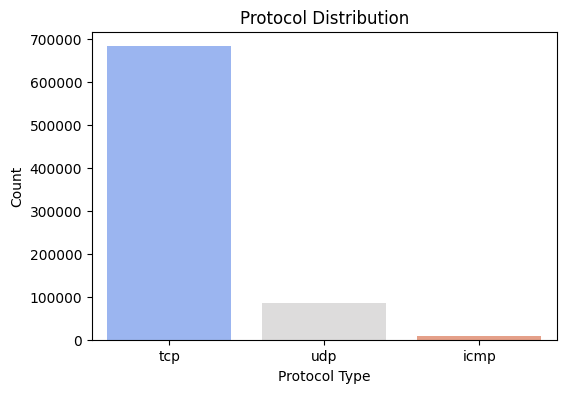

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='proto', data=data, palette='coolwarm')
plt.title("Protocol Distribution")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

Comparing protocol distribution across attack classes

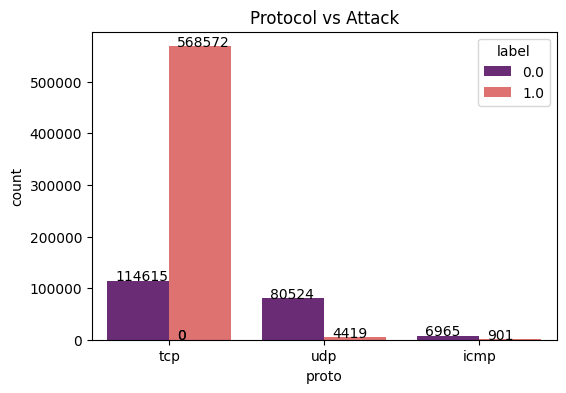

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='proto', hue='label', data=data, palette='magma')

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+0.05, p.get_height()+500))

plt.title("Protocol vs Attack")
plt.show()

Visualizing feature relationships using pairplot

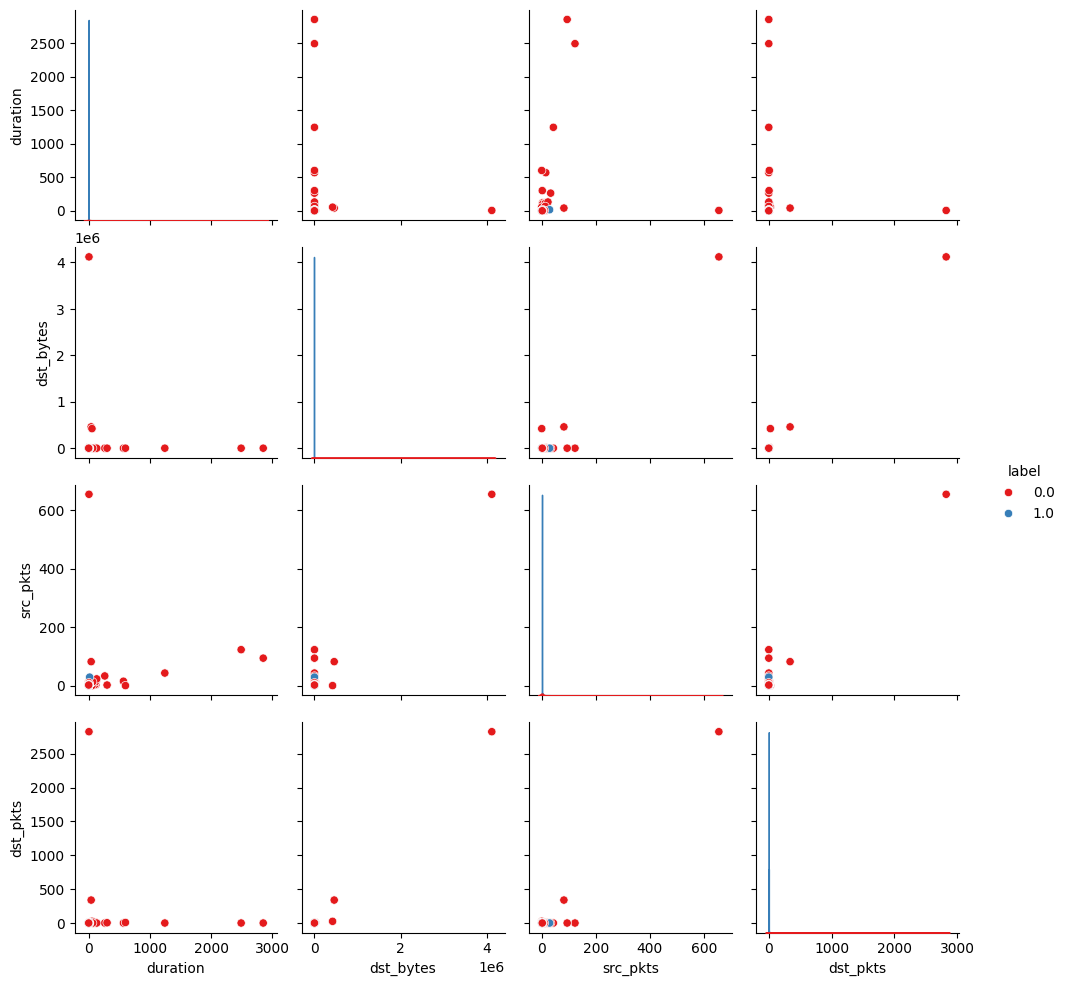

In [ ]:
sample_data = data.sample(5000)

sns.pairplot(
    sample_data[['duration','src_bytes','dst_bytes','src_pkts','dst_pkts','label']],
    hue='label',
    palette='Set1'
)
plt.show()

Converting byte features to numeric values

In [ ]:
data['src_bytes'] = pd.to_numeric(data['src_bytes'], errors='coerce')
data['dst_bytes'] = pd.to_numeric(data['dst_bytes'], errors='coerce')
plot_df = data[['src_bytes', 'dst_bytes', 'label']].dropna()

Visualizing traffic bytes relationship using scatterplot

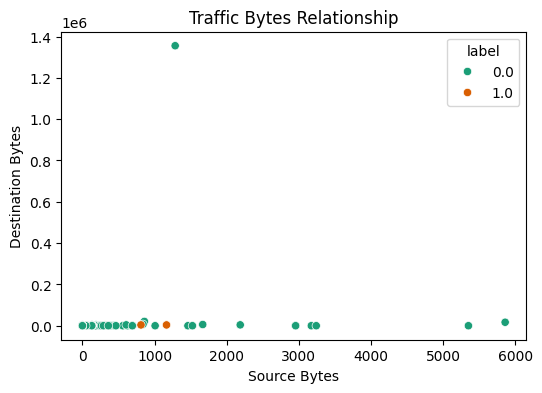

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='src_bytes',
    y='dst_bytes',
    hue='label',
    data=plot_df.sample(5000, random_state=42),
    palette='Dark2'
)

plt.title("Traffic Bytes Relationship")
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")
plt.show()

Visualizing feature correlations using heatmap

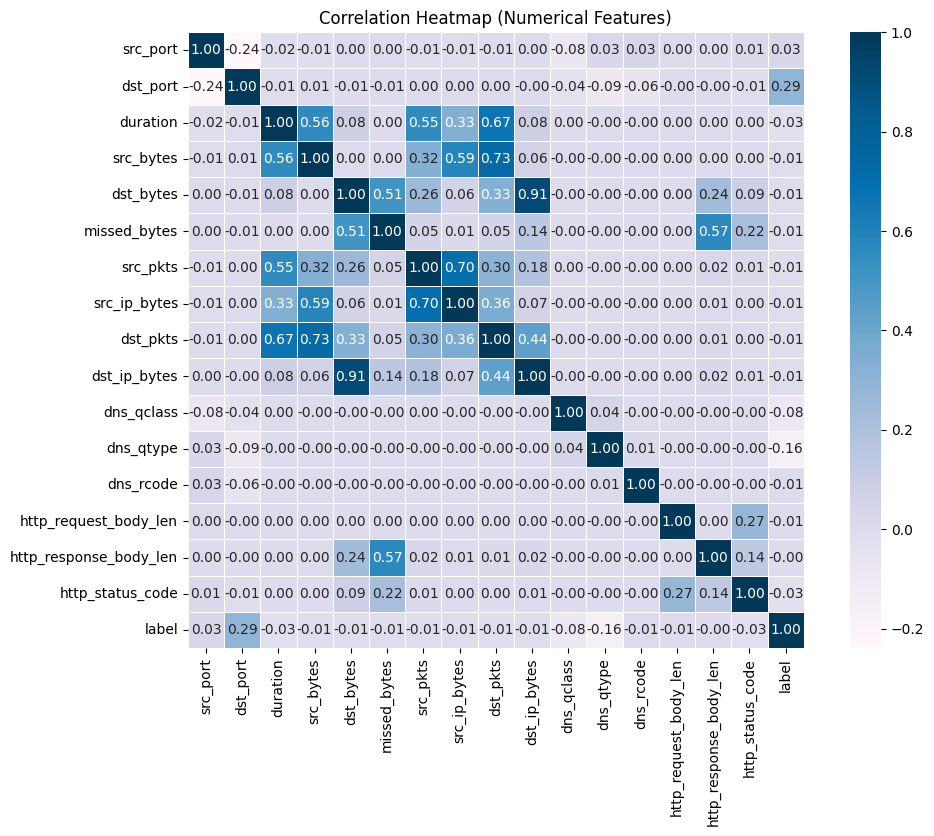

In [ ]:
plt.figure(figsize=(12,8))

numeric_data = data.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_data.corr(),
    cmap="PuBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap (Numerical Features)")

plt.show()

Visualizing connection state distribution using countplot

/tmp/ipykernel_4740/1925901377.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='conn_state', data=data, palette='cubehelix')


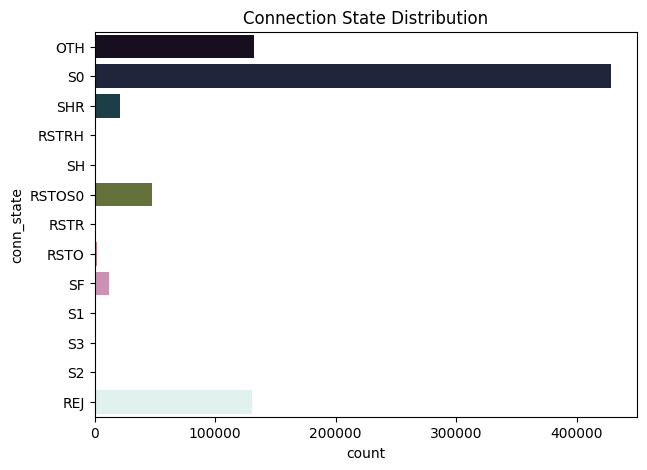

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(y='conn_state', data=data, palette='cubehelix')
plt.title("Connection State Distribution")
plt.show()

Visualizing top destination ports frequency

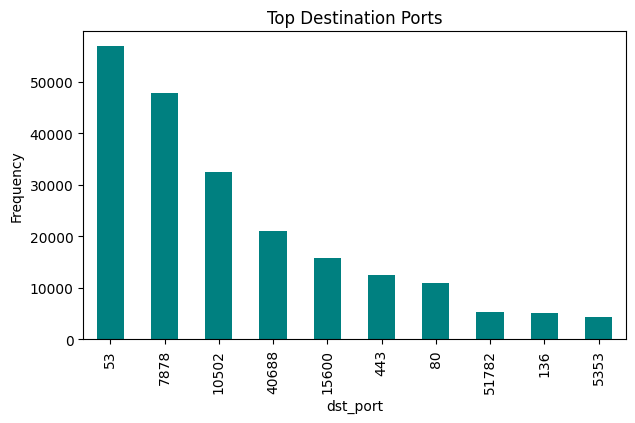

In [ ]:
top_ports = data['dst_port'].value_counts().head(10)

plt.figure(figsize=(7,4))
top_ports.plot(kind='bar', color='teal')
plt.title("Top Destination Ports")
plt.ylabel("Frequency")
plt.show()


Visualizing duration versus destination bytes relationship

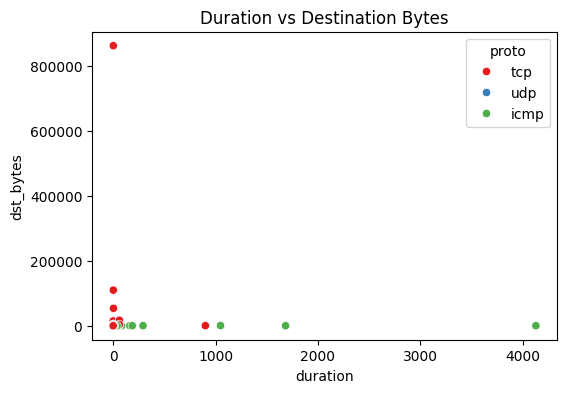

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='duration',
    y='dst_bytes',
    hue='proto',
    data=data.sample(5000),
    palette='Set1'
)
plt.title("Duration vs Destination Bytes")
plt.show()

Replacing dashes and converting numeric values

In [ ]:
#Replacing
data.replace('-', np.nan, inplace=True)

# Converting numeric columns
for col in data.columns:
    try:
        data[col] = pd.to_numeric(data[col])
    except:
        pass

Imputing missing values using median and mode

In [ ]:
# Filling missing values
for col in data.columns:
    if data[col].dtype in ['float64', 'int64']:
        data[col].fillna(data[col].median(), inplace=True)
    else:
        data[col].fillna(data[col].mode()[0], inplace=True)

print("Missing values after handling:", data.isnull().sum().sum())

/tmp/ipykernel_4740/2894028791.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_4740/2894028791.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Missing values after handling: 0



Dropping identifiers and encoding categorical features

In [ ]:
drop_cols = ['ts', 'src_ip', 'dst_ip']
data.drop(columns=[col for col in drop_cols if col in data.columns], inplace=True)
#Encoding
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

Preparing features and target for classification

In [ ]:
# Binary classification
X = data.drop(['label', 'type'], axis=1)
y = data['label']

print("Final Shape:", X.shape)

Final Shape: (775997, 18)


Splitting dataset and selecting important features

In [ ]:
#Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
# Reducing feature complexity
selector = SelectKBest(score_func=f_classif, k=15)
X = selector.fit_transform(X, y)

Scaling features using StandardScaler

In [ ]:
#Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Evaluating model performance using multiple metrics

In [ ]:
#Evaluation
def plot_results(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    print(f"\n===== {model_name} REPORT =====")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    try:
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0,1],[0,1],'--')
        plt.title(f"{model_name} - ROC Curve")
        plt.legend()
        plt.show()
    except:
        print("ROC not available")

Applying SMOTE to balance class distribution

In [ ]:
#APPLYING SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_smote))

Before SMOTE: [151578 430419]
After SMOTE: [430419 430419]


Training Logistic Regression model on balanced data

In [ ]:
#LogisticRegression
lr = LogisticRegression(
    max_iter=200,
    C=0.5,
    class_weight='balanced'
)
lr.fit(X_smote, y_smote)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=200)

Evaluating Logistic Regression performance on test data


===== Logistic Regression REPORT =====
              precision    recall  f1-score   support

         0.0       0.70      0.97      0.81     50526
         1.0       0.99      0.85      0.91    143474

    accuracy                           0.88    194000
   macro avg       0.84      0.91      0.86    194000
weighted avg       0.91      0.88      0.89    194000



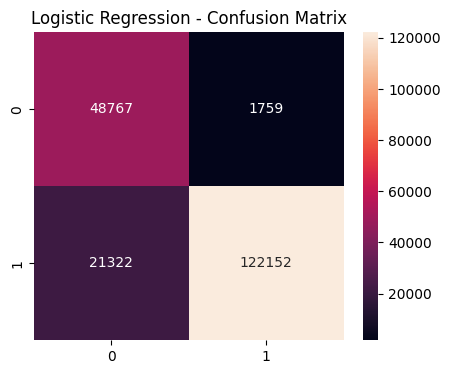

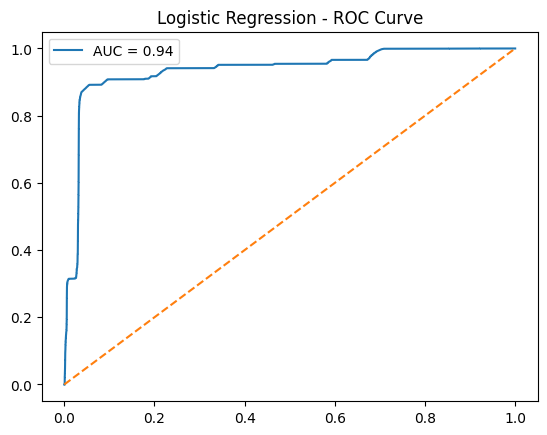

In [ ]:
plot_results(lr, X_test, y_test, "Logistic Regression")

Training Decision Tree model on balanced data

In [ ]:
#DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10
)

dt.fit(X_smote, y_smote)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20)

Evaluating Decision Tree performance on test data


===== Decision Tree REPORT =====
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98     50526
         1.0       1.00      0.98      0.99    143474

    accuracy                           0.99    194000
   macro avg       0.98      0.99      0.98    194000
weighted avg       0.99      0.99      0.99    194000



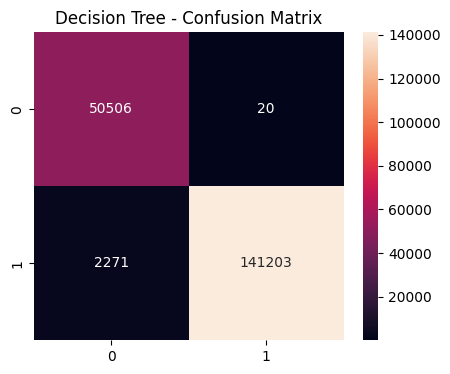

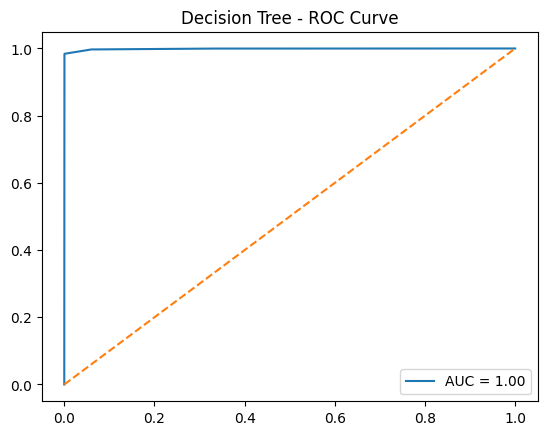

In [ ]:
plot_results(dt, X_test, y_test, "Decision Tree")

Training Random Forest Classifier on Balanced Data

In [ ]:
#RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=4,
    min_samples_split=20,
    random_state=42
)
rf.fit(X_smote, y_smote)

RandomForestClassifier(max_depth=4, min_samples_split=20, n_estimators=30,
                       random_state=42)

Evaluating Random Forest Classifier on test data


===== Random Forest REPORT =====
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     50526
         1.0       1.00      1.00      1.00    143474

    accuracy                           1.00    194000
   macro avg       0.99      1.00      0.99    194000
weighted avg       1.00      1.00      1.00    194000



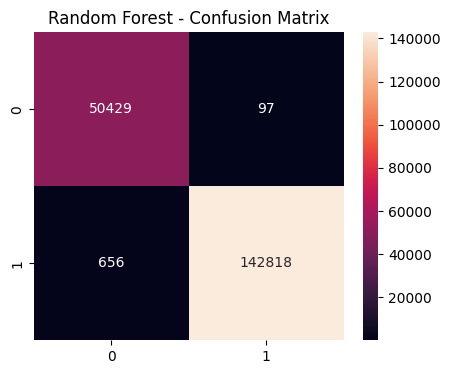

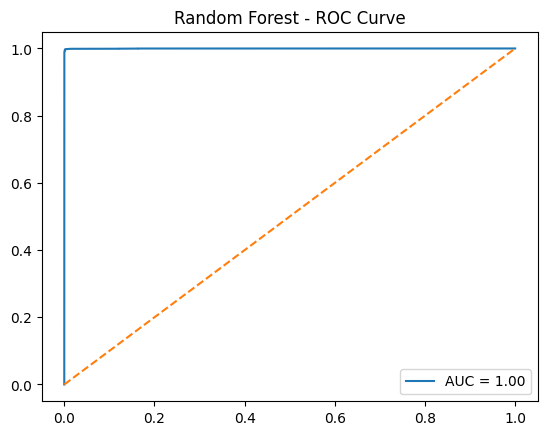

In [ ]:
plot_results(rf, X_test, y_test, "Random Forest")

Training SVM model on balanced data

In [ ]:
#SVM
svm = LinearSVC(
    C=0.5,
    max_iter=2000
)

svm = CalibratedClassifierCV(svm)
svm.fit(X_smote, y_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


CalibratedClassifierCV(estimator=LinearSVC(C=0.5, max_iter=2000))

Evaluating SVM model performance on test data


===== Fast SVM REPORT =====
              precision    recall  f1-score   support

         0.0       0.70      0.96      0.81     50526
         1.0       0.99      0.85      0.91    143474

    accuracy                           0.88    194000
   macro avg       0.84      0.91      0.86    194000
weighted avg       0.91      0.88      0.89    194000



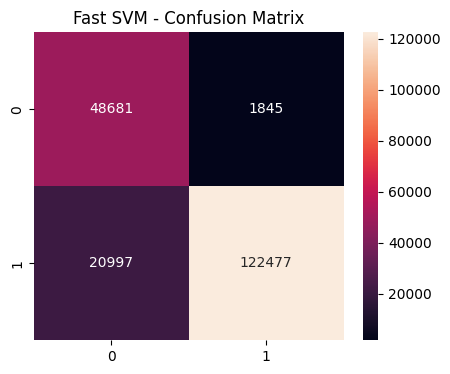

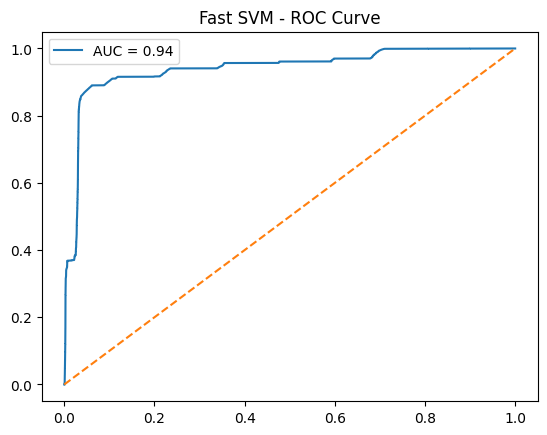

In [ ]:
plot_results(svm, X_test, y_test, "Fast SVM")

Training Isolation Forest on balanced data

In [ ]:
#IsolationForest
iso = IsolationForest(
    contamination=0.2,
    n_estimators=50,
    random_state=42
)

iso.fit(X_train)
y_pred_iso = iso.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

Evaluating Isolation Forest model performance

In [ ]:
print("Isolation Forest REPORT")
print(classification_report(y_test, y_pred_iso))

Isolation Forest REPORT
              precision    recall  f1-score   support

         0.0       0.16      0.51      0.25     50526
         1.0       0.27      0.06      0.10    143474

    accuracy                           0.18    194000
   macro avg       0.22      0.29      0.17    194000
weighted avg       0.24      0.18      0.14    194000



Visualizing Isolation Forest confusion matrix

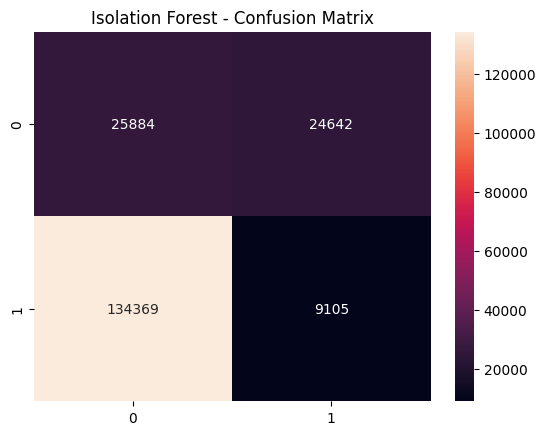

In [ ]:
cm = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Isolation Forest - Confusion Matrix")
plt.show()

Comparing models using F1-score evaluation

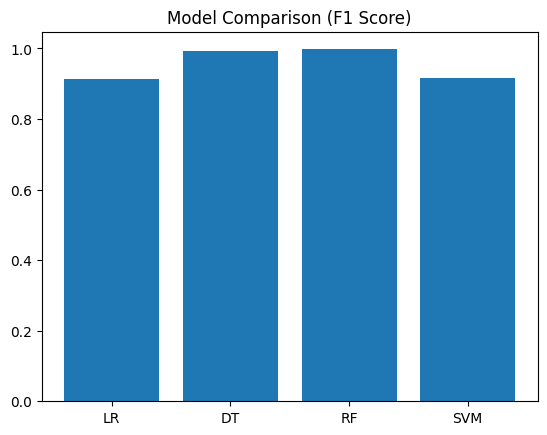

In [ ]:
models = {
    "LR": lr,
    "DT": dt,
    "RF": rf,
    "SVM": svm
}

scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    scores[name] = f1_score(y_test, y_pred)

plt.figure()
plt.bar(scores.keys(), scores.values())
plt.title("Model Comparison (F1 Score)")
plt.show()

Evaluating models using multiple performance metrics

In [ ]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 3),
        "F1 Score": round(f1_score(y_test, y_pred, zero_division=0), 3)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1 Score", ascending=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LR,0.881,0.986,0.851,0.914
3,SVM,0.882,0.985,0.854,0.915
1,DT,0.988,1.000,0.984,0.992
2,RF,0.996,0.999,0.995,0.997


 Visualizing model accuracy comparison using bar chart

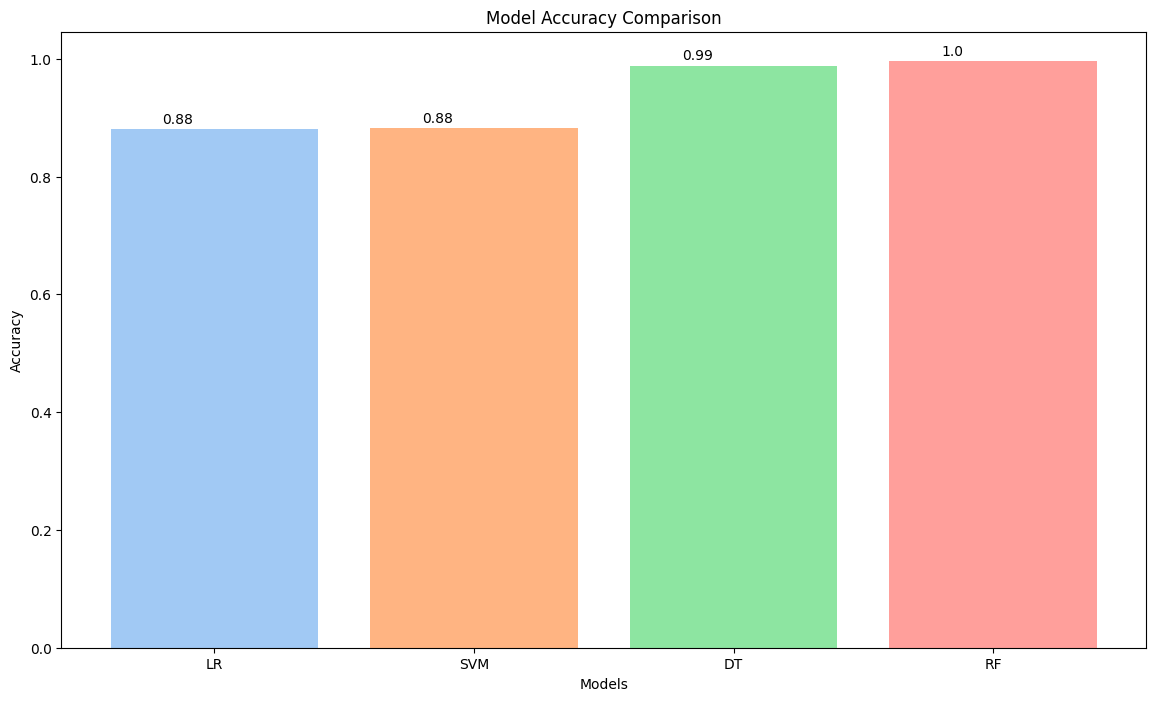

In [ ]:
#Accuracy
plt.figure(figsize=(14,8))

bars = plt.bar(results_df["Model"], results_df["Accuracy"],
               color=sns.color_palette("pastel"))

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.2, yval + 0.01, round(yval, 2))

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

Visualizing feature importance using Random Forest

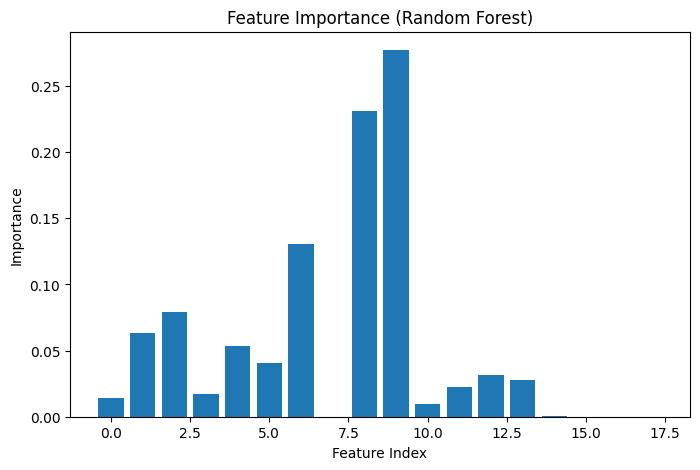

In [ ]:
#Feature importance
importances = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

Visualizing top important features using bar chart

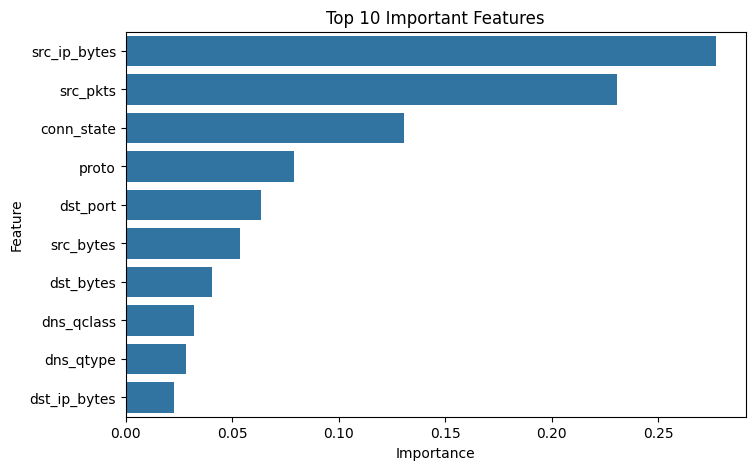

In [ ]:
#TOP IMPORTANT FEATURES
feature_names = data.drop(['label'], axis=1).columns[:len(importances)]

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 10 Important Features")
plt.show()

Analyzing false positives and false negatives

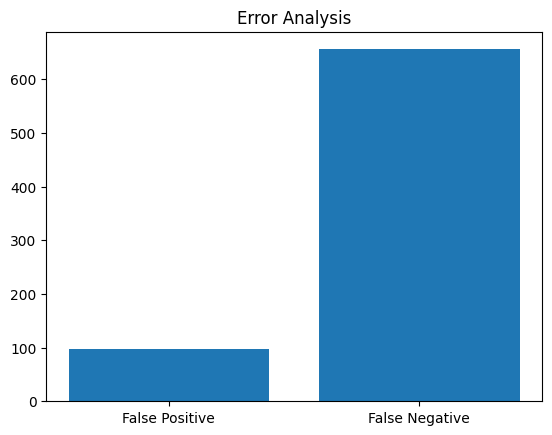

In [ ]:
#ERROR ANALYSIS
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fp = cm[0][1]
fn = cm[1][0]

plt.figure()
plt.bar(["False Positive", "False Negative"], [fp, fn])
plt.title("Error Analysis")
plt.show()

Ranking models based on F1-score performance

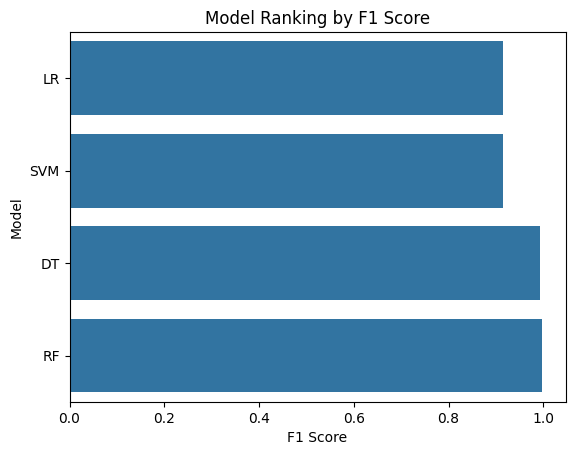

In [ ]:
#F1 score
plt.figure()
sns.barplot(x="F1 Score", y="Model", data=results_df)
plt.title("Model Ranking by F1 Score")
plt.show()